Dataset Shape:
(34833, 35)

Missing Values:
Length%_2017-07-01 00:00:00      14699
Facings%_2017-07-01 00:00:00     14699
DisplayS%_2017-07-01 00:00:00    14348
PSKU%_2017-07-01 00:00:00         6920
STAR5_Achievement                    0
dtype: int64

Missing After Cleaning:
Length%_2017-07-01 00:00:00      0
Facings%_2017-07-01 00:00:00     0
DisplayS%_2017-07-01 00:00:00    0
PSKU%_2017-07-01 00:00:00        0
STAR5_Achievement                0
dtype: int64

Scaled Values:
   Length%_2017-07-01 00:00:00  Facings%_2017-07-01 00:00:00  \
0                    -0.193657                     -0.195099   
1                    -0.193657                     -0.195099   
2                    -0.193657                     -0.195099   
3                     0.531007                      0.901744   
4                     1.318059                      1.070027   

   DisplayS%_2017-07-01 00:00:00  PSKU%_2017-07-01 00:00:00  STAR5_Achievement  
0                      -0.204686                  -1.

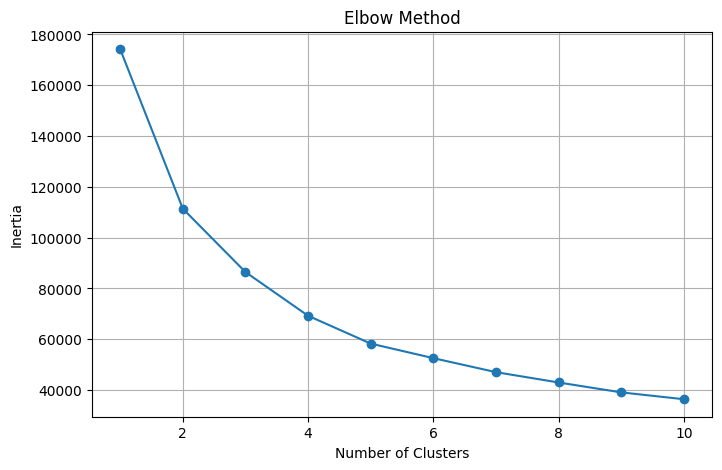

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# ==========================
# LOAD DATA
# ==========================

df = pd.read_excel("Final_Merged_Store_SKU.xlsx")
print("Dataset Shape:")
print(df.shape)


# ==========================
# SELECT FEATURES
# ==========================

features = [
"Length%_2017-07-01 00:00:00",
"Facings%_2017-07-01 00:00:00",
"DisplayS%_2017-07-01 00:00:00",
"PSKU%_2017-07-01 00:00:00",
"STAR5_Achievement"
]
X = df[features]

# ==========================
# CHECK MISSING VALUES
# ==========================

print("\nMissing Values:")
print(X.isnull().sum())

# ==========================
# HANDLE NULL VALUES
# (Median)
# ==========================

imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=features)
print("\nMissing After Cleaning:")
print(X_imputed.isnull().sum())

# ==========================
# SCALE DATA
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_imputed)
scaled_df = pd.DataFrame(X_scaled, columns=features)

print("\nScaled Values:")
print(scaled_df.head())

# ==========================
# ELBOW METHOD
# ==========================

inertia=[]
k_values=range(1,11)
for k in k_values:
    model=KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertia.append(model.inertia_)
    
# ==========================
# ELBOW VISUAL
# ==========================

plt.figure(figsize=(8,5))
plt.plot(k_values,inertia,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()





Cluster Summary
         Length%_2017-07-01 00:00:00  Facings%_2017-07-01 00:00:00  \
Cluster                                                              
0                          29.677900                     29.946887   
1                          13.540254                     12.674832   
2                          75.578366                     74.095969   

         DisplayS%_2017-07-01 00:00:00  PSKU%_2017-07-01 00:00:00  \
Cluster                                                             
0                            50.016808                  77.109727   
1                            11.358321                  63.942492   
2                            90.335764                  68.159934   

         STAR5_Achievement  
Cluster                     
0                54.858819  
1                17.034637  
2               105.037463  

Stores in each Cluster
Cluster
1    20343
0    12121
2     2369
Name: count, dtype: int64


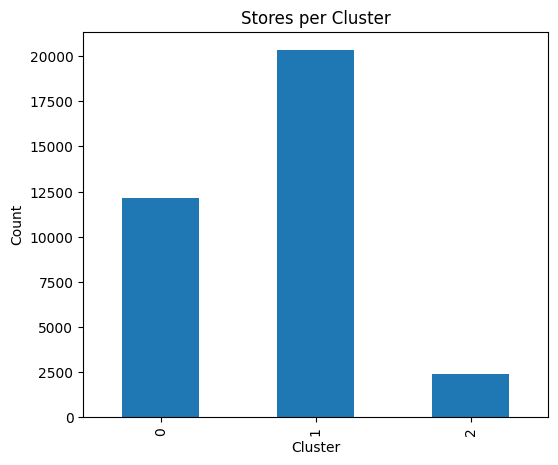

In [17]:
# ==========================
# FINAL KMEANS
# ==========================

k=3

kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# ==========================
# CLUSTER SUMMARY
# ==========================

summary = (df.groupby("Cluster")[features].mean())
print("\nCluster Summary")
print(summary)

# ==========================
# CLUSTER SIZE
# ==========================

print("\nStores in each Cluster")
print(df["Cluster"].value_counts())

# ==========================
# VISUALIZE CLUSTERS
# ==========================

cluster_count=(df["Cluster"].value_counts().sort_index())
plt.figure(figsize=(6,5))
cluster_count.plot(kind="bar")
plt.title("Stores per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

Dataset Shape:
(34833, 35)

Missing Values:
Region                               0
Length%_2017-07-01 00:00:00      14699
Facings%_2017-07-01 00:00:00     14699
DisplayS%_2017-07-01 00:00:00    14348
PSKU%_2017-07-01 00:00:00         6920
STAR5_Achievement                    0
dtype: int64

Region Encoding
{'East': 0, 'North': 1, 'South': 2, 'West': 3}

Scaled Data
   Region_Encoded  Length%_2017-07-01 00:00:00  Facings%_2017-07-01 00:00:00  \
0       -1.285051                    -0.193657                     -0.195099   
1        0.409908                    -0.193657                     -0.195099   
2       -0.437571                    -0.193657                     -0.195099   
3        0.409908                     0.531007                      0.901744   
4        1.257388                     1.318059                      1.070027   

   DisplayS%_2017-07-01 00:00:00  PSKU%_2017-07-01 00:00:00  STAR5_Achievement  
0                      -0.204686                  -1.483727           

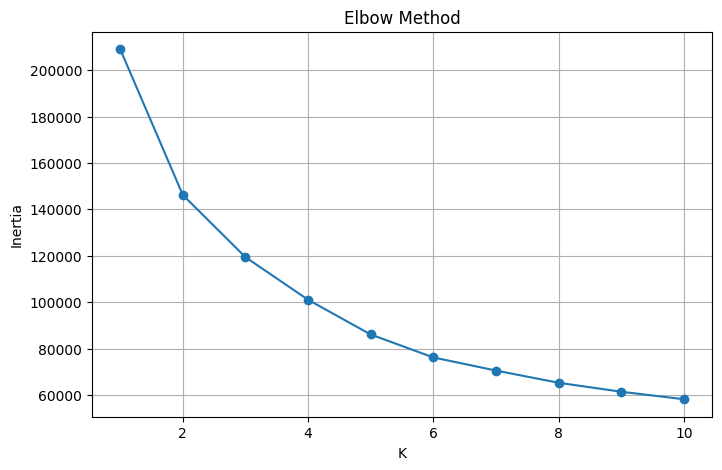


Cluster Summary
         Length%_2017-07-01 00:00:00  Facings%_2017-07-01 00:00:00  \
Cluster                                                              
0                          19.534827                     19.162433   
1                          73.400004                     72.079848   
2                          19.469268                     18.975618   

         DisplayS%_2017-07-01 00:00:00  PSKU%_2017-07-01 00:00:00  \
Cluster                                                             
0                            26.276535                  68.869989   
1                            86.905868                  68.682724   
2                            26.084491                  69.048945   

         STAR5_Achievement  
Cluster                     
0                30.710818  
1               102.008372  
2                31.170577  

Region Cluster Table
Cluster     0    1     2
Region                  
East        0  702  8861
North       0  670  7389
South    6307  567 

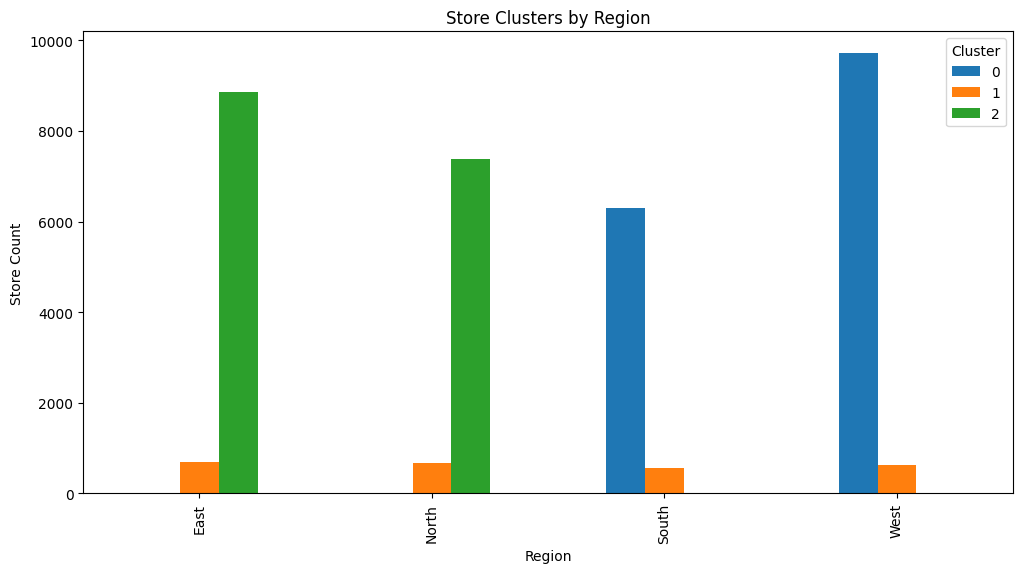


File Saved


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans



# ==================================
# LOAD DATA
# ==================================

df = pd.read_excel(
    "Final_Merged_Store_SKU.xlsx"
)

print("Dataset Shape:")
print(df.shape)



# ==================================
# SELECT FEATURES
# ==================================

features = [

"Region",

"Length%_2017-07-01 00:00:00",

"Facings%_2017-07-01 00:00:00",

"DisplayS%_2017-07-01 00:00:00",

"PSKU%_2017-07-01 00:00:00",

"STAR5_Achievement"

]

cluster_df = df[features].copy()



# ==================================
# CHECK NULLS
# ==================================

print("\nMissing Values:")

print(
cluster_df.isnull().sum()
)



# ==================================
# HANDLE REGION NULLS
# ==================================

cluster_df["Region"] = (

cluster_df

["Region"]

.fillna(
"Unknown"
)

)



# ==================================
# ENCODE REGION
# ==================================

encoder = LabelEncoder()

cluster_df["Region_Encoded"] = (

encoder

.fit_transform(

cluster_df["Region"]

)

)

print("\nRegion Encoding")

print(

dict(

zip(

encoder.classes_,

range(
len(
encoder.classes_
)
)

)

)

)



# ==================================
# HANDLE NUMERIC NULLS
# ==================================

num_cols=[

"Length%_2017-07-01 00:00:00",

"Facings%_2017-07-01 00:00:00",

"DisplayS%_2017-07-01 00:00:00",

"PSKU%_2017-07-01 00:00:00",

"STAR5_Achievement"

]

imputer = SimpleImputer(
strategy="median"
)

cluster_df[num_cols] = (

imputer

.fit_transform(

cluster_df[num_cols]

)

)



# ==================================
# FINAL INPUT
# ==================================

X = cluster_df[

[

"Region_Encoded",

"Length%_2017-07-01 00:00:00",

"Facings%_2017-07-01 00:00:00",

"DisplayS%_2017-07-01 00:00:00",

"PSKU%_2017-07-01 00:00:00",

"STAR5_Achievement"

]

]



# ==================================
# SCALE
# ==================================

scaler = StandardScaler()

X_scaled = (

scaler

.fit_transform(X)

)



print("\nScaled Data")

print(

pd.DataFrame(

X_scaled,

columns=X.columns

).head()

)



# ==================================
# ELBOW METHOD
# ==================================

inertia=[]

K=range(
1,
11
)

for k in K:

    model = KMeans(

        n_clusters=k,

        random_state=42,

        n_init=10

    )

    model.fit(
        X_scaled
    )

    inertia.append(
        model.inertia_
    )



plt.figure(
figsize=(8,5)
)

plt.plot(
K,
inertia,
marker="o"
)

plt.title(
"Elbow Method"
)

plt.xlabel(
"K"
)

plt.ylabel(
"Inertia"
)

plt.grid()

plt.show()






# ==================================
# FINAL CLUSTERING
# ==================================

optimal_k = 3


kmeans = KMeans(

n_clusters=optimal_k,

random_state=42,

n_init=10

)

cluster_df["Cluster"] = (

kmeans

.fit_predict(

X_scaled

)

)



df["Cluster"] = (

cluster_df["Cluster"]

)



# ==================================
# CLUSTER SUMMARY
# ==================================

summary = (

df

.groupby(
"Cluster"
)

[

num_cols

]

.mean()

)

print(
"\nCluster Summary"
)

print(
summary
)



# ==================================
# REGION VS CLUSTER
# ==================================

region_cluster = (

df

.groupby(
[
"Region",
"Cluster"
]
)

.size()

.unstack(

fill_value=0

)

)

print(
"\nRegion Cluster Table"
)

print(
region_cluster
)



# ==================================
# VISUAL
# ==================================

region_cluster.plot(

kind="bar",

figsize=(12,6)

)

plt.title(
"Store Clusters by Region"
)

plt.xlabel(
"Region"
)

plt.ylabel(
"Store Count"
)

plt.show()



# ==================================
# SAVE
# ==================================

df.to_excel(

"Store_Region_Clustered.xlsx",

index=False

)

print(
"\nFile Saved"
)